<a href="https://colab.research.google.com/github/kittimaxz/Study/blob/main/medical_data_visualizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/freeCodeCamp/boilerplate-medical-data-visualizer/main/medical_examination.csv')
df

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [6]:
# 2. Add an overweight column to the data.
# Calculate BMI: weight (kg) / (height (m) ^ 2). Height is provided in cm, so divide by 100.
bmi = df['weight'] / ((df['height'] / 100) ** 2)
df['overweight'] = (bmi > 25).astype(int)
df

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,1
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,1


In [7]:
# 3. Normalize data by making 0 always good and 1 always bad.
# If the value of cholesterol or gluc is 1, set the value to 0. If more than 1, set to 1.
df['cholesterol'] = (df['cholesterol'] > 1).astype(int)
df['gluc'] = (df['gluc'] > 1).astype(int)
df

,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,overweight
0,0,18393,2,168,62.0,110,80,0,0,0,0,1,0,0
1,1,20228,1,156,85.0,140,90,1,0,0,0,1,1,1
2,2,18857,1,165,64.0,130,70,1,0,0,0,0,1,0
3,3,17623,2,169,82.0,150,100,0,0,0,0,1,1,1
4,4,17474,1,156,56.0,100,60,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,0,0,1,0,1,0,1
69996,99995,22601,1,158,126.0,140,90,1,1,0,0,1,1,1
69997,99996,19066,2,183,105.0,180,90,1,0,0,1,0,1,1
69998,99998,22431,1,163,72.0,135,80,0,1,0,0,0,1,1


In [11]:
# 4. Draw the Categorical Plot in the draw_cat_plot function.
def draw_cat_plot():
    # 5. Create a DataFrame for the cat plot using pd.melt with values from cholesterol,
    # gluc, smoke, alco, active, and overweight in the df_cat variable.
    df_cat = pd.melt(
        df,
        id_vars=['cardio'],
        value_vars=['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'overweight']
    )

    # 6. Group and reformat the data in df_cat to split it by cardio. Show the counts of each feature.
    # We group by cardio, variable, and value, then reset index and rename the size column to 'total'.
    df_cat = df_cat.groupby(['cardio', 'variable', 'value']).size().reset_index(name='total')

    # 7. Convert the data into long format and create a chart using sns.catplot()
    fig = sns.catplot(
        x='variable',
        y='total',
        hue='value',
        col='cardio',
        data=df_cat,
        kind='bar'
    ).fig

    # 8. Get the figure for the output and store it in the fig variable.
    # (Achieved above by adding .fig to the catplot generation)

    # 9. Do not modify the next two lines.
    fig.savefig('catplot.png')
    return fig

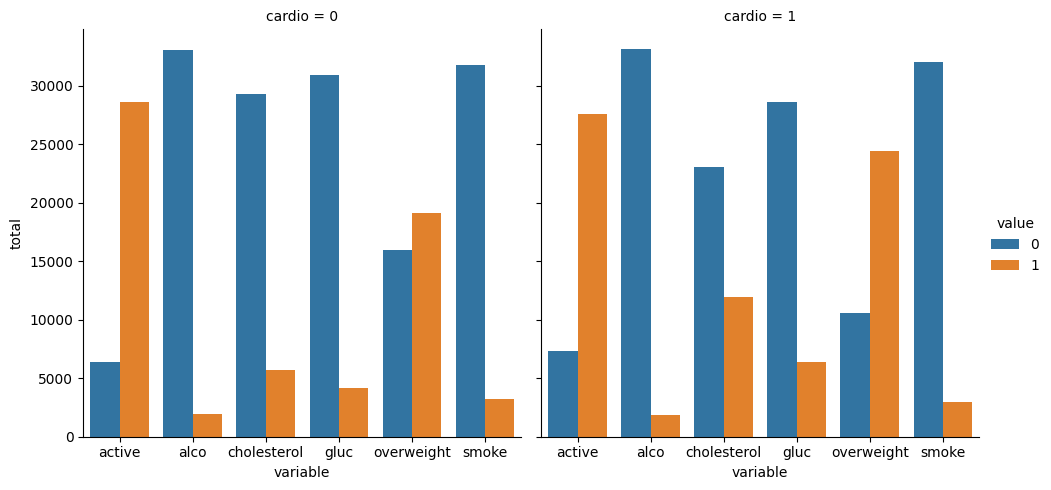

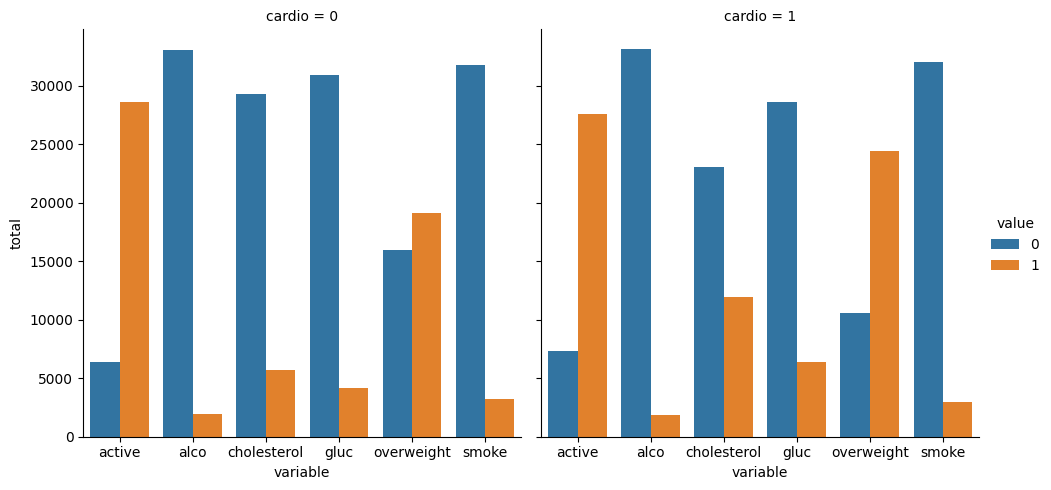

In [12]:
draw_cat_plot()

In [13]:
# 10. Draw the Heat Map in the draw_heat_map function.
def draw_heat_map():
    # 11. Clean the data in the df_heat variable by filtering out incorrect patient segments.
    df_heat = df[
        (df['ap_lo'] <= df['ap_hi']) &
        (df['height'] >= df['height'].quantile(0.025)) &
        (df['height'] <= df['height'].quantile(0.975)) &
        (df['weight'] >= df['weight'].quantile(0.025)) &
        (df['weight'] <= df['weight'].quantile(0.975))
    ]

    # 12. Calculate the correlation matrix and store it in the corr variable.
    corr = df_heat.corr()

    # 13. Generate a mask for the upper triangle and store it in the mask variable.
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # 14. Set up the matplotlib figure.
    fig, ax = plt.subplots(figsize=(12, 12))

    # 15. Plot the correlation matrix using sns.heatmap()
    sns.heatmap(
        corr,
        mask=mask,
        annot=True,
        fmt='.1f',
        center=0,
        vmin=-0.1,
        vmax=0.25,
        square=True,
        linewidths=.5,
        cbar_kws={'shrink': .5}
    )

    # 16. Do not modify the next two lines.
    fig.savefig('heatmap.png')
    return fig

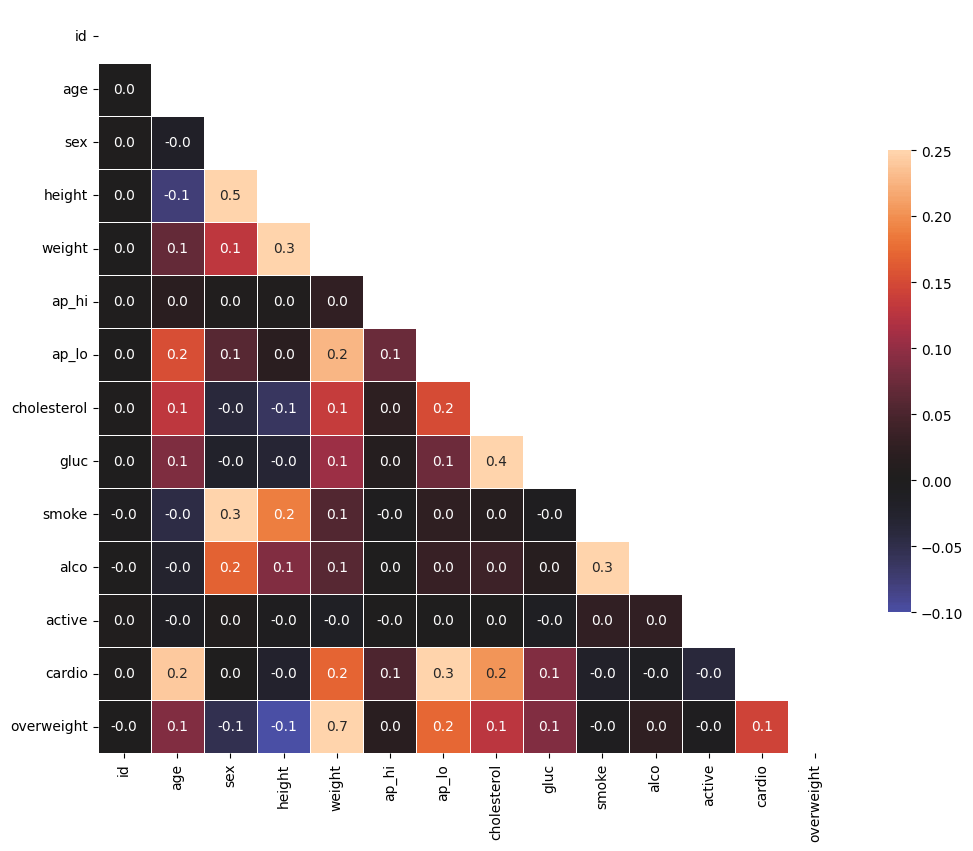

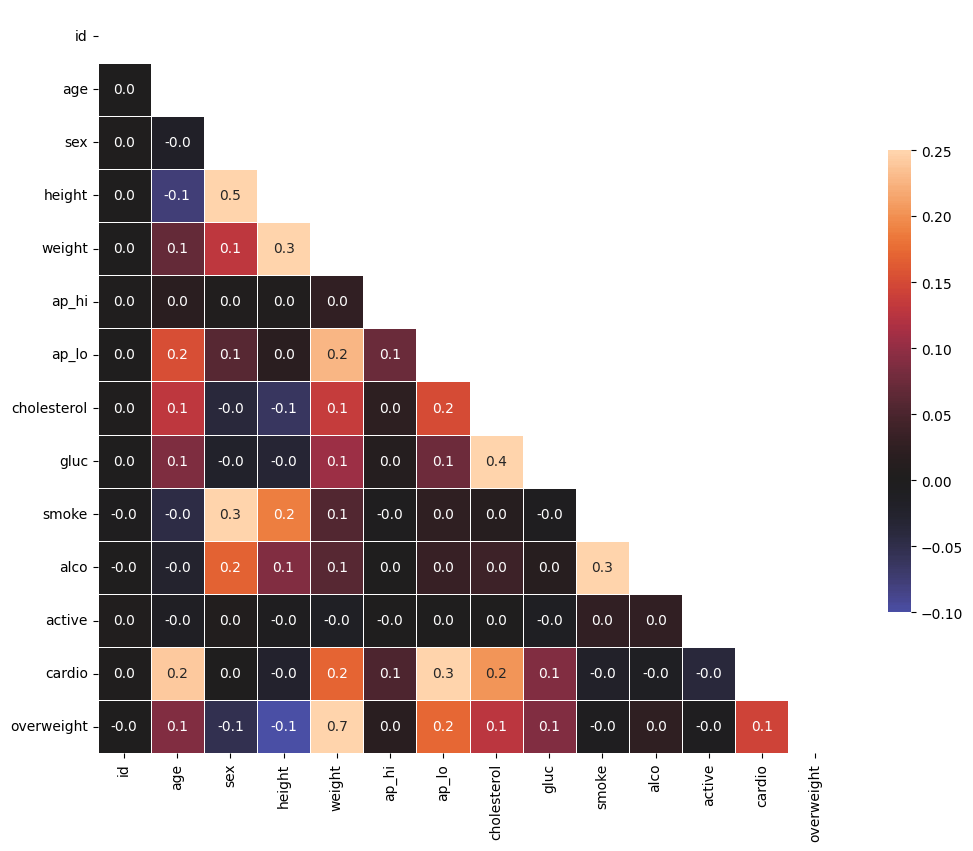

In [14]:
draw_heat_map()